#**Avocado sales analysis**


Работу выполнили Антонова Арина и Григорьева Полина, студентки группы ИД24-1

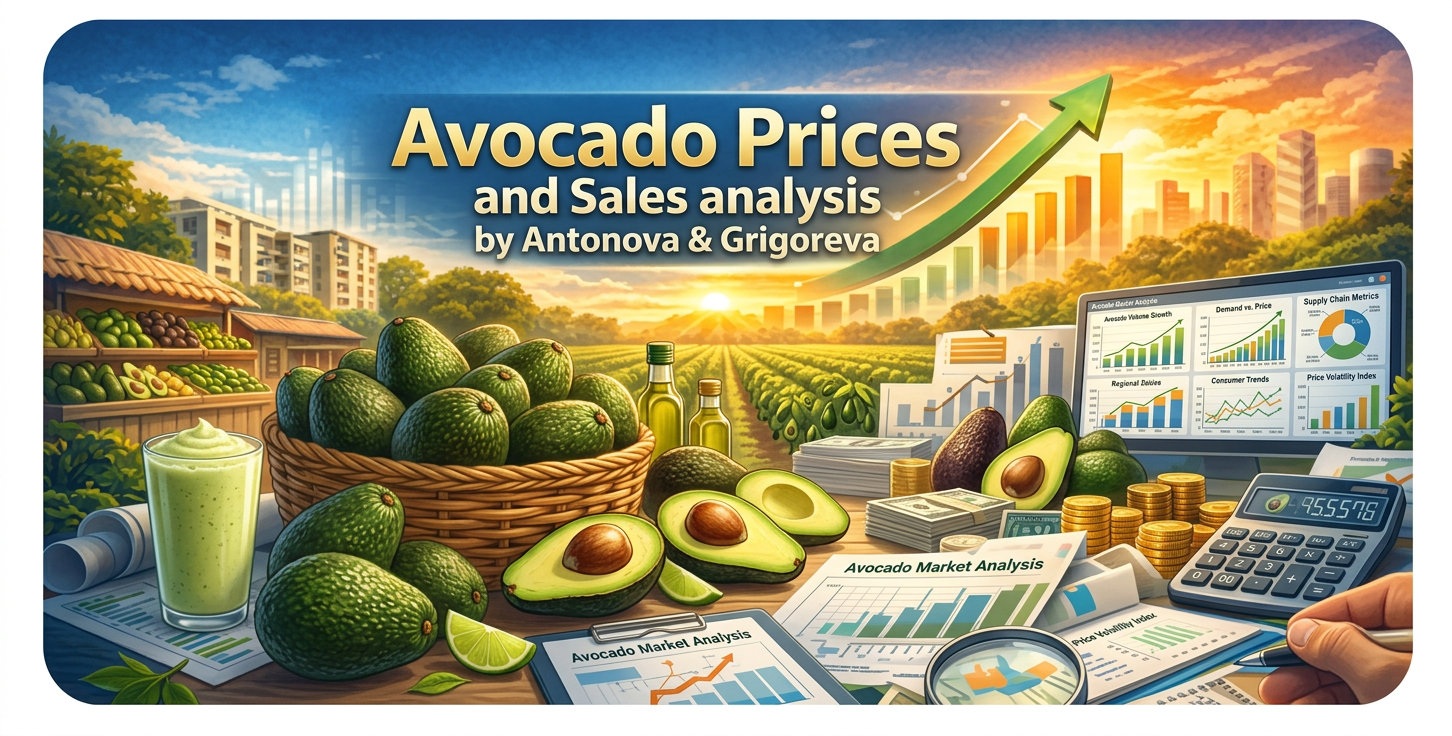

##Постановка задачи

####Cведения о датасете

Этот проект посвящен анализу рынка авокадо в США и построению модели для прогнозирования средней цены на основе исторических данных о продажах. Датасет содержит исторические данные за период 2015–2023 гг: дату наблюдения, среднюю цену, общий объём продаж, объёмы продаж по PLU-кодам, данные по типам упаковки, а также тип продукта — conventional или organic.

<img src="https://github.com/zloyevrey25/avocado-pic/blob/main/ee623f3093237dfa13cc0bad42ea54b8%20(1).png?raw=true" width="300">

####Цель и задачи проекта

Главная цель проекта - разработать и обосновать модель машинного обучения, которая способна с приемлемой точностью прогнозировать среднюю цену на авокадо (AveragePrice) на основе исторических данных о продажах, типе продукта и регионе.

Для достижения этой цели мы поставили перед собой следующие задачи:

* Провести разведочный анализ данных (EDA): Изучить данные, найти в них закономерности, аномалии и взаимосвязи. Визуализировать распределения цен, объемов продаж и проанализировать динамику по времени.


* Выполнить предобработку данных: Подготовить данные для моделирования - обработать пропуски (если они есть), закодировать категориальные признаки и нормализовать числовые признаки.


* Построить и обучить несколько моделей:
Начать с простой baseline-модели.
Обучить несколько классических моделей ML (например, решающее дерево, k-ближайших соседей).


* Применить ансамблевые модели (случайный лес, градиентный бустинг), чтобы добиться более высокой точности.


* Оценить качество моделей: Сравнить модели между собой с помощью стандартных метрик для регрессии - RMSE, MAE и R². Выбрать лучшую модель для дальнейшей работы.


* Подобрать гиперпараметры: Для лучшей модели провести подбор гиперпараметров, чтобы дополнительно улучшить ее качество.
Интерпретировать результаты: Проанализировать важность признаков, чтобы понять, какие факторы сильнее всего влияют на цену авокадо.

####Бизнес-задача

Необходимо разработать модель машинного обучения для прогнозирования средней цены на авокадо на основе исторических данных о продажах. Точный прогноз цен позволяет принимать более обоснованные управленческие решения в бизнесе, такие как:

* оптимизация закупок (покупать товар заранее при ожидаемом росте цен);
* управление запасами (избегать дефицита и излишков);
* планирование маркетинговых акций (например, скидок при ожидаемом снижении цен).

####Тип задачи

Основной тип задачи, которую мы решаем, - это регрессия, так как мы предсказываем непрерывное числовое значение (цену).

Поскольку в данных есть временной столбец (Date), задачу также можно рассматривать как прогнозирование временных рядов. Это позволит нам анализировать тренды и сезонность, что может быть ключом к построению более точной модели.

##Данные

####Загрузка датасета, общая информация

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

In [ ]:
import kagglehub

path = kagglehub.dataset_download("vakhariapujan/avocado-prices-and-sales-volume-2015-2023")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'avocado-prices-and-sales-volume-2015-2023' dataset.
Path to dataset files: /kaggle/input/avocado-prices-and-sales-volume-2015-2023


In [ ]:
import os

files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]

print("CSV files:", csv_files)

df = pd.read_csv(f"{path}/{csv_files[0]}")
display(df.head())
print(df.shape)
print(df.columns)
df.info()

CSV files: ['Avocado_HassAvocadoBoard_20152023v1.0.1.csv']


,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,BaltimoreWashington


(53415, 12)
Index(['Date', 'AveragePrice', 'TotalVolume', 'plu4046', 'plu4225', 'plu4770',
       'TotalBags', 'SmallBags', 'LargeBags', 'XLargeBags', 'type', 'region'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53415 entries, 0 to 53414
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          53415 non-null  object 
 1   AveragePrice  53415 non-null  float64
 2   TotalVolume   53415 non-null  float64
 3   plu4046       53415 non-null  float64
 4   plu4225       53415 non-null  float64
 5   plu4770       53415 non-null  float64
 6   TotalBags     53415 non-null  float64
 7   SmallBags     41025 non-null  float64
 8   LargeBags     41025 non-null  float64
 9   XLargeBags    41025 non-null  float64
 10  type          53415 non-null  object 
 11  region        53415 non-null  object 
dtypes: float64(9), object(3)
memory usage: 4.9+ MB


In [ ]:
df.describe()

,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags
count,53415.000000,5.341500e+04,5.341500e+04,5.341500e+04,5.341500e+04,5.341500e+04,4.102500e+04,4.102500e+04,41025.000000
mean,1.428910,8.694474e+05,2.982707e+05,2.222170e+05,2.053195e+04,2.175083e+05,1.039222e+05,2.331316e+04,2731.811796
std,0.393116,3.545274e+06,1.307669e+06,9.554624e+05,1.040977e+05,8.676947e+05,5.692608e+05,1.496622e+05,22589.096454
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.119091,1.626465e+04,6.947250e+02,2.120800e+03,0.000000e+00,7.846520e+03,0.000000e+00,0.000000e+00,0.000000
50%,1.400000,1.203525e+05,1.458058e+04,1.751663e+04,9.005000e+01,3.695310e+04,6.945800e+02,0.000000e+00,0.000000
75%,1.690000,4.542380e+05,1.287924e+05,9.351560e+04,3.599735e+03,1.110146e+05,3.795298e+04,2.814920e+03,0.000000
max,3.440830,6.103446e+07,2.544720e+07,2.047057e+07,2.860025e+06,1.629830e+07,1.256716e+07,4.324231e+06,679586.800000


##Предобработка

####Очистка от выбросов и пустых значений

In [ ]:
df.isnull().sum()

,0
Date,0
AveragePrice,0
TotalVolume,0
plu4046,0
plu4225,0
plu4770,0
TotalBags,0
SmallBags,12390
LargeBags,12390
XLargeBags,12390


In [ ]:
Q1 = df['AveragePrice'].quantile(0.25)
Q3 = df['AveragePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_price = (df['AveragePrice'] < lower_bound) | (df['AveragePrice'] > upper_bound)

print(f"Количество выбросов в средней стоимости: {outliers_price.sum()}")

Количество выбросов в средней стоимости: 358


In [ ]:
df = df[~outliers_price]

In [ ]:
missing_rows = df[df[['SmallBags', 'LargeBags', 'XLargeBags']].isnull().any(axis=1)]

for index, row in missing_rows.iterrows():
    random_percentages = np.random.dirichlet(np.ones(3), size=1)[0]

    remaining_value = row['TotalBags'] - row[['SmallBags', 'LargeBags', 'XLargeBags']].sum()

    df.at[index, 'SmallBags'] = remaining_value * random_percentages[0]
    df.at[index, 'LargeBags'] = remaining_value * random_percentages[1]
    df.at[index, 'XLargeBags'] = remaining_value * random_percentages[2]

print(df[['TotalBags', 'SmallBags', 'LargeBags', 'XLargeBags']].isnull().sum())

TotalBags     0
SmallBags     0
LargeBags     0
XLargeBags    0
dtype: int64


####Кодирование категорий

In [ ]:
df_plot = df.copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'], errors='coerce')
df_plot['Year'] = df_plot['Date'].dt.year
df_plot['Month'] = df_plot['Date'].dt.month
df_plot['Day'] = df_plot['Date'].dt.day

In [ ]:
df_ml = df.copy()
df_ml['Date'] = pd.to_datetime(df_ml['Date'], errors='coerce')
df_ml['Year'] = df_ml['Date'].dt.year.astype('category')
df_ml['Month'] = df_ml['Date'].dt.month.astype('category')
df_ml['Day'] = df_ml['Date'].dt.day.astype('category')
df_ml = df_ml.drop(columns=['Date'])
df_ml = pd.get_dummies(df_ml, columns=['Year', 'Month', 'Day'], drop_first=True, dtype=int)

####Feature engineering (создание новых признаков)

In [ ]:
#доли PLU в общем объёме продаж
df_ml['share_4046'] = df_ml['plu4046'] / (df_ml['TotalVolume'] + 1e-8)
df_ml['share_4225'] = df_ml['plu4225'] / (df_ml['TotalVolume'] + 1e-8)
df_ml['share_4770'] = df_ml['plu4770'] / (df_ml['TotalVolume'] + 1e-8)

In [ ]:
#доли разных типов пакетов
df_ml['small_bags_share'] = df_ml['SmallBags'] / (df_ml['TotalBags'] + 1e-8)
df_ml['large_bags_share'] = df_ml['LargeBags'] / (df_ml['TotalBags'] + 1e-8)
df_ml['xlarge_bags_share'] = df_ml['XLargeBags'] / (df_ml['TotalBags'] + 1e-8)

In [ ]:
df_ml.head()

,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,...,Day_28,Day_29,Day_30,Day_31,share_4046,share_4225,share_4770,small_bags_share,large_bags_share,xlarge_bags_share
0,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,...,0,0,0,0,0.068981,0.692076,0.001221,0.945502,0.054498,0.0
1,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,...,0,0,0,0,0.041792,0.111998,0.000000,1.000000,0.000000,0.0
2,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,...,0,0,0,0,0.837435,0.054759,0.000189,0.356870,0.643130,0.0
3,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,...,0,0,0,0,0.389985,0.243937,0.000000,0.760799,0.239201,0.0
4,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,...,0,0,0,0,0.068510,0.701635,0.050754,0.971725,0.028275,0.0


####Нормализация

In [ ]:
#до нормализации
numeric_cols = df_ml.select_dtypes(include='number').columns.drop('AveragePrice')
df_before_scaling = df_ml[numeric_cols].describe().T[['mean', 'std', 'min', 'max']]
df_before_scaling.head()

,mean,std,min,max
TotalVolume,875212.455374,3.556518e+06,84.56,61034457.10
plu4046,300267.279569,1.311847e+06,0.00,25447201.87
plu4225,223669.070595,9.585162e+05,0.00,20470572.61
plu4770,20670.390824,1.044346e+05,0.00,2860025.19
TotalBags,218951.392559,8.704387e+05,0.00,16298296.29


In [ ]:
#после нормализации
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_ml[numeric_cols] = scaler.fit_transform(df_ml[numeric_cols])

df_after_scaling = df_ml[numeric_cols].describe().T[['mean', 'std', 'min', 'max']]
df_after_scaling.head()

,mean,std,min,max
TotalVolume,-2.678413e-19,1.000009,-0.246065,16.915370
plu4046,2.142730e-18,1.000009,-0.228891,19.169287
plu4225,-5.892508e-18,1.000009,-0.233351,21.123371
plu4770,0.000000e+00,1.000009,-0.197928,27.188127
TotalBags,-4.017619e-18,1.000009,-0.251544,18.472865


До нормализации признаки были в разных масштабах. Например, TotalVolume, plu4046, TotalBags измерялись в сотнях тысяч и миллионах, поэтому их значения были сильно больше, чем у других признаков.

После применения StandardScaler среднее значение каждого числового признака стало близко к 0, а стандартное отклонение - близко к 1. Это значит, что признаки приведены к единому масштабу.

##Анализ данных (Exploraroty data analysis)

####Графики

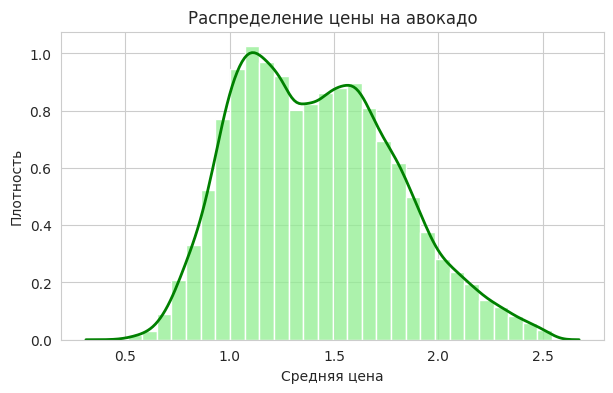

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df_plot["AveragePrice"], bins=30, stat="density", color="lightgreen")
sns.kdeplot(df_plot["AveragePrice"], color="green", linewidth=2)
plt.title("Распределение цены на авокадо")
plt.xlabel("Средняя цена")
plt.ylabel("Плотность")
plt.show()

На графике видно, что чаще всего средняя цена авокадо находится примерно в диапазоне от 1 до 1.7. Очень низкие и очень высокие цены встречаются реже. Также видно, что распределение не идеально ровное: есть несколько пиков, значит в данных могут быть разные группы наблюдений.

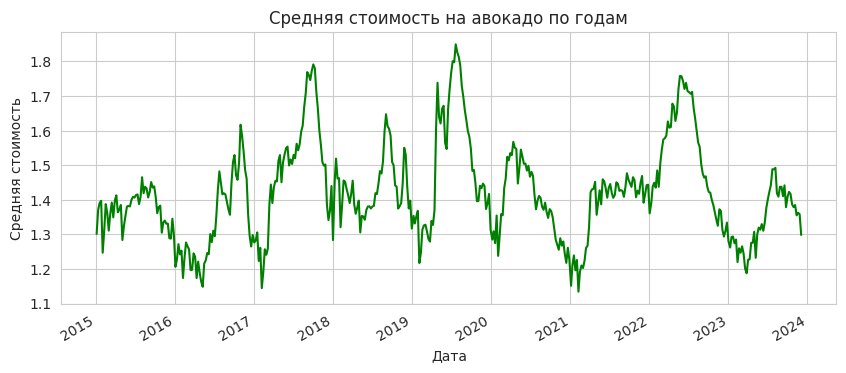

In [ ]:
plt.figure(figsize=(10,4))
df_plot.groupby("Date")["AveragePrice"].mean().plot(color = 'green')
plt.title("Средняя стоимость на авокадо по годам")
plt.xlabel("Дата")
plt.ylabel("Средняя стоимость")
plt.show()

График показывает, что средняя цена на авокадо со временем изменяется неравномерно и имеет выраженные колебания. Наблюдаются периодические подъёмы и спады.

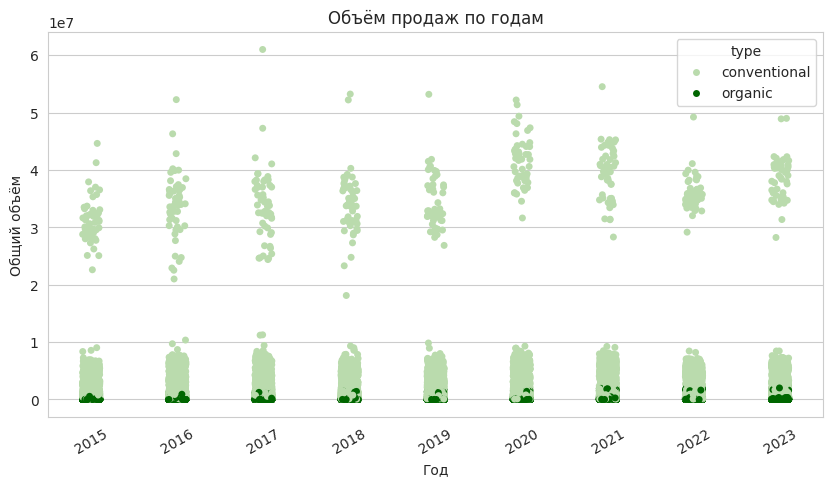

In [ ]:
green_palette = {'conventional': '#badbad', 'organic': '#006600'}

plt.figure(figsize=(10, 5))
ax = sns.stripplot(x=df_plot['Year'], y=df_plot['TotalVolume'], hue=df_plot['type'], palette=green_palette)
ax.set_title('Объём продаж по годам')
ax.set_xlabel('Год')
ax.set_ylabel('Общий объём')
plt.xticks(rotation=30)
plt.show()

График показывает, что объём продаж авокадо со временем увеличивается: в более поздние годы наблюдаются более высокие значения по сравнению с ранними. Также видно, что объёмы продаж conventional значительно превышают объёмы organic, что свидетельствует о более высокой распространённости обычного авокадо.

/tmp/ipykernel_39320/2353513859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='type', y='AveragePrice', palette={'conventional': '#badbad', 'organic': '#006600'})


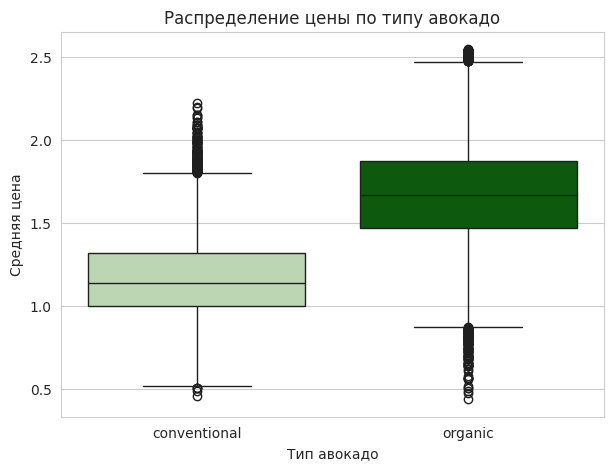

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_plot, x='type', y='AveragePrice', palette={'conventional': '#badbad', 'organic': '#006600'})
plt.title('Распределение цены по типу авокадо')
plt.xlabel('Тип авокадо')
plt.ylabel('Средняя цена')
plt.show()

График показывает, что organic-авокадо в среднем имеет более высокую цену по сравнению с conventional. Также на графике присутствуют выбросы, особенно для высоких цен, что может быть связано с сезонностью или региональными особенностями продаж.

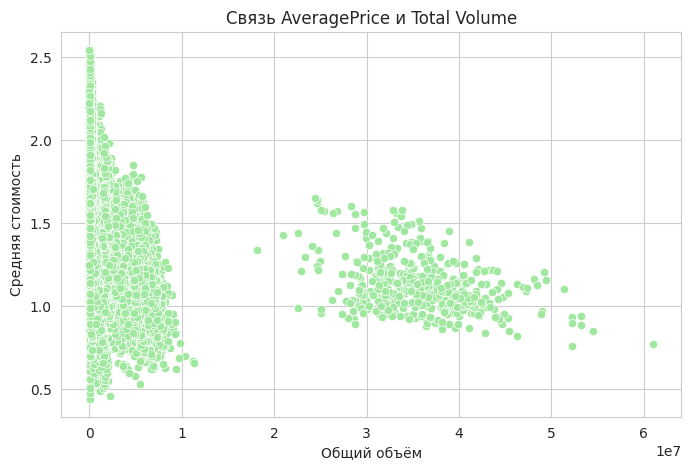

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_plot, x='TotalVolume', y='AveragePrice', color='#a0e8a0')
plt.title('Связь AveragePrice и Total Volume')
plt.xlabel('Общий объём')
plt.ylabel('Средняя стоимость')
plt.show()

На графике наблюдается слабая отрицательная зависимость между объёмом продаж и ценой: при увеличении объёма продаж средняя цена снижается. Также видно, что при малых объёмах разброс цен значительно выше, тогда как при больших объёмах значения цены более стабильны и сосредоточены в узком диапазоне.

####Анализ распределений

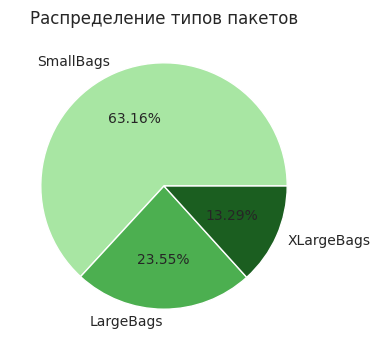

In [ ]:
total_small_bags = df_plot['SmallBags'].sum()
total_large_bags = df_plot['LargeBags'].sum()
total_xlarge_bags = df_plot['XLargeBags'].sum()

sizes = [total_small_bags, total_large_bags, total_xlarge_bags]
labels = ['SmallBags', 'LargeBags', 'XLargeBags']
colors = ['#a8e6a3', '#4caf50', '#1b5e20']

plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, colors=colors, autopct='%.2f%%')
plt.title('Распределение типов пакетов')
plt.show()

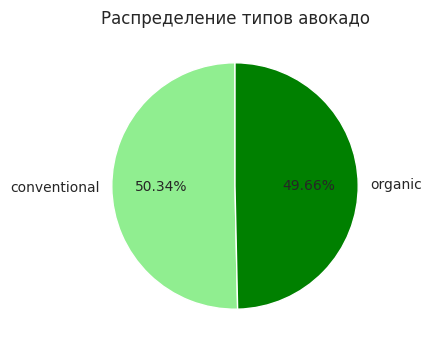

In [ ]:
type_distribution = df_plot['type'].value_counts()

sizes = type_distribution.values
labels = type_distribution.index
colors = ['lightgreen', 'green']

plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, colors=colors, autopct='%.2f%%', startangle=90)
plt.title('Распределение типов авокадо')
plt.show()

####Корреляции

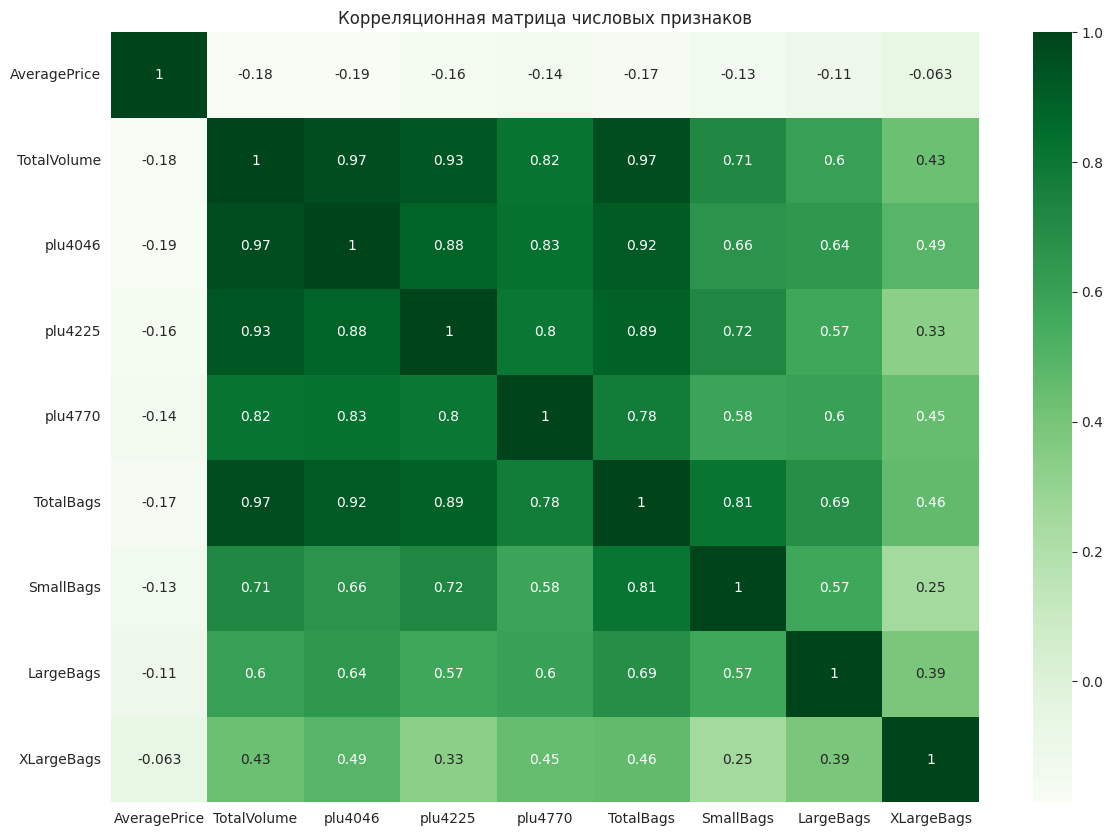

In [ ]:
numeric_cols = ['AveragePrice','TotalVolume','plu4046','plu4225','plu4770',
                'TotalBags','SmallBags','LargeBags','XLargeBags']
plt.figure(figsize=(14, 10))
sns.heatmap(df_plot[numeric_cols].corr(), cmap='Greens', annot=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

Цена (AveragePrice) слабо связана с остальными признаками и имеет небольшую отрицательную корреляцию. При этом все признаки, связанные с объёмами (TotalVolume, TotalBags и др.), сильно связаны между собой. Это значит, что они описывают примерно одно и то же (объём продаж).

##Моделирование

####Baseline модель

In [ ]:
df_ml = pd.get_dummies(df_ml, columns=['type', 'region'], drop_first=True, dtype=int)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns=['AveragePrice'])
y = df_ml['AveragePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

MAE: 0.44314559877537374
RMSE: 0.5787073366867991
R2: 0.6669159518257648


####Классические модели ML

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2:", r2_score(y_test, y_pred_dt))

MAE: 0.3185935968418785
RMSE: 0.4738460232787574
R2: 0.7766888859724903


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2:", r2_score(y_test, y_pred_knn))

MAE: 0.5094053595228384
RMSE: 0.6589602238133506
R2: 0.5681287847894134


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))

MAE: 0.5299725223047725
RMSE: 0.679861179955192
R2: 0.5402980509140325


####Ансамблевые модели

In [ ]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor

base_models = [
    ('linear', LinearRegression()),
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('lasso', Lasso(alpha=0.01, random_state=42, max_iter=10000))
]

meta_model = RandomForestRegressor(random_state=42)

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_stack))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_stack)))
print("R2:", r2_score(y_test, y_pred_stack))

MAE: 0.2948453932789865
RMSE: 0.407202691706858
R2: 0.8350861472030673


##Оценка качества

####Regression: RMSE, MAE, R²

MAE показывает среднюю абсолютную ошибку модели. В нашем случае она показывает, на сколько долларов в среднем прогнозируемая цена авокадо отличается от реальной.

RMSE показывает среднеквадратичную ошибку. Она сильнее штрафует большие ошибки, поэтому полезна, если для задачи важно избегать крупных отклонений в прогнозе цены.

R² показывает, какую долю разброса целевой переменной объясняет модель. Чем ближе значение R² к 1, тем лучше модель описывает данные.

Для MAE и RMSE меньшие значения означают лучшее качество модели.

Для R² большее значение означает лучшее качество модели.


####Сравнительная таблица моделей

In [ ]:
df = pd.DataFrame()
df['name'] = ['LinearRegression','DecisionTreeRegressor','KNeighborsRegressor','Lasso','StackingRegressor']
df['MAE'] = [mean_absolute_error(y_test, y_pred_lr),mean_absolute_error(y_test, y_pred_dt),mean_absolute_error(y_test, y_pred_knn),mean_absolute_error(y_test, y_pred_lasso),mean_absolute_error(y_test, y_pred_stack)]
df['RMSE'] = [np.sqrt(mean_squared_error(y_test, y_pred_lr)),np.sqrt(mean_squared_error(y_test, y_pred_dt)),np.sqrt(mean_squared_error(y_test, y_pred_knn)),np.sqrt(mean_squared_error(y_test, y_pred_lasso)),np.sqrt(mean_squared_error(y_test, y_pred_stack))]
df['R2'] = [r2_score(y_test, y_pred_lr),r2_score(y_test, y_pred_dt),r2_score(y_test, y_pred_knn),r2_score(y_test, y_pred_lasso),r2_score(y_test, y_pred_stack)]

df.sort_values(by=["MAE"], inplace=True)
cm = sns.light_palette("lightgreen", as_cmap=True)
s = df.style.background_gradient(cmap=cm)
s

,name,MAE,RMSE,R2
4,StackingRegressor,0.294845,0.407203,0.835086
1,DecisionTreeRegressor,0.318594,0.473846,0.776689
0,LinearRegression,0.443146,0.578707,0.666916
2,KNeighborsRegressor,0.509405,0.658960,0.568129
3,Lasso,0.529973,0.679861,0.540298


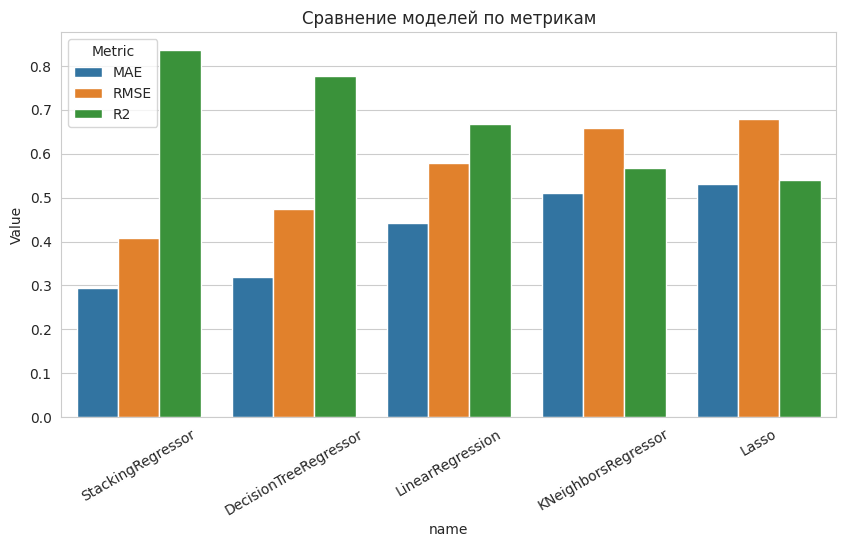

In [ ]:
df_melted = df.melt(id_vars='name', value_vars=['MAE', 'RMSE', 'R2'],
                    var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 5))
sns.barplot(x='name', y='Value', hue='Metric', data=df_melted)
plt.title('Сравнение моделей по метрикам')
plt.xticks(rotation=30)
plt.show()

##Подбор гиперпараметров

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'tree__max_depth': [10, 15],
    'tree__min_samples_leaf': [5, 7],
    'knn__n_neighbors': [3, 12],
    'lasso__alpha': [0.01, 0.1],}

In [ ]:
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=2)

In [ ]:
grid_search = GridSearchCV(
    estimator=stacking_model,
    param_grid=param_grid,
    cv=2,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

In [ ]:
grid_search.fit(X_train, y_train)
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший RMSE:", -grid_search.best_score_)

Лучшие параметры: {'knn__n_neighbors': 3, 'lasso__alpha': 0.01, 'tree__max_depth': 15, 'tree__min_samples_leaf': 5}
Лучший RMSE: 0.4785568579195788


In [ ]:
best_model = grid_search.best_estimator_
best_model

StackingRegressor(cv=2,
                  estimators=[('linear', LinearRegression()),
                              ('tree',
                               DecisionTreeRegressor(max_depth=15,
                                                     min_samples_leaf=5,
                                                     random_state=42)),
                              ('knn', KNeighborsRegressor(n_neighbors=3)),
                              ('lasso',
                               Lasso(alpha=0.01, max_iter=10000,
                                     random_state=42))],
                  final_estimator=RandomForestRegressor(random_state=42))

## Интерпретация

####Feature importance

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Признак': feature_names,
    'Важность': importances}).sort_values(by='Важность', ascending=False)

importance_df.head()

,Признак,Важность
63,type_organic,0.598626
58,share_4225,0.048036
1,plu4046,0.031614
2,plu4225,0.030747
14,Year_2022,0.023544


Для объяснения решений модели была использована важность признаков Random Forest. Наиболее важным признаком оказался type_organic, что означает сильное влияние типа продукта на среднюю цену. Это логично, так как organic-авокадо обычно отличается по стоимости от conventional. Также модель учитывает структуру продаж по PLU-кодам и временные признаки.

##Проверка гипотез

**Гипотеза 1:** organic-авокадо имеет более высокую цену по сравнению с conventional.

Результат: гипотеза подтвердилась. Анализ важности признаков показал, что type_organic является самым значимым признаком для модели. Это говорит о сильном влиянии типа продукта на цену.

**Гипотеза 2:** цена изменяется со временем и зависит от сезонных факторов.

Результат: гипотеза подтвердилась. Анализ временных графиков и важности признаков показал, что модель учитывает временные характеристики, связанные с годом и месяцем продаж.

**Гипотеза 3:** при увеличении объёма продаж средняя цена снижается.

Результат: гипотеза частично подтвердилась. Корреляционная матрица и диаграмма рассеяния показали слабую отрицательную связь между TotalVolume и AveragePrice.

**Гипотеза 4:** объёмы продаж разных типов авокадо сильно связаны между собой.

Результат: гипотеза подтвердилась. Корреляционная матрица показала высокую положительную связь между TotalVolume, plu4046, plu4225 и TotalBags. Это означает, что признаки описывают близкие характеристики продаж.

**Гипотеза 5:** цена авокадо сильно зависит от общего объёма продаж.

Результат: гипотеза не подтвердилась. Корреляция между AveragePrice и TotalVolume оказалась слабой отрицательной, около -0.18. Это значит, что связь есть, но она слабая, поэтому общий объём продаж сам по себе не может хорошо объяснить изменение цены.

**Гипотеза 6:** feature engineering улучшает информативность данных.

Результат: гипотеза подтвердилась. Созданные признаки, такие как доли PLU-кодов и логарифм объёма продаж, использовались моделью при прогнозировании и вошли в число значимых факторов.

**Гипотеза 7:** модели машинного обучения способны выявлять нелинейные зависимости между признаками и ценой.

Результат: гипотеза подтвердилась. Ансамблевые модели показали более высокое качество по сравнению с линейной регрессией, что указывает на наличие сложных зависимостей в данных.

##Архитектура

In [ ]:
import joblib
joblib.dump(best_model, 'best_avocado_price_model.pkl')

['best_avocado_price_model.pkl']

<img src= "https://raw.githubusercontent.com/zloyevrey25/avocado-pic/4f1f418f495be6e010086b38be08611b7a241a82/801b04f8-b4b6-4d08-84e3-cb5383d39a96.png" width = 900>